### Assignment 1 (3 scores):

- Use the Numpy library only to construct the Linear Regression model.
- Train and Evaluate that Linear Regression model on the [Forest Fires](https://archive.ics.uci.edu/static/public/162/forest+fires.zip) dataset.

In [29]:
import numpy as np
import pandas as pd

In [30]:
class Linear_Regression:
    def __init__(self):
        self.theta_ = None

    def rmse(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        delta = y - y_hat
        return np.sqrt((delta**2).mean())

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        cov_1 = np.matmul(X.T, X)
        inv_cov_1  = np.linalg.inv(cov_1)
        cov_2 = np.matmul(X.T, y)
        self.theta_ = np.matmul(inv_cov_1, cov_2)

    def predict(self, X: np.ndarray) -> np.ndarray:
        y_predict = X @ self.theta_.T
        return y_predict

In [31]:
data = pd.read_csv("forestfires.csv")
print(data.head(10))

   X  Y month  day  FFMC    DMC     DC   ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.0
5  8  6   aug  sun  92.3   85.3  488.0  14.7  22.2  29   5.4   0.0   0.0
6  8  6   aug  mon  92.3   88.9  495.6   8.5  24.1  27   3.1   0.0   0.0
7  8  6   aug  mon  91.5  145.4  608.2  10.7   8.0  86   2.2   0.0   0.0
8  8  6   sep  tue  91.0  129.5  692.6   7.0  13.1  63   5.4   0.0   0.0
9  7  5   sep  sat  92.5   88.0  698.6   7.1  22.8  40   4.0   0.0   0.0


In [32]:
month = {
    "jan": 1,
    "feb": 2,
    "mar": 3,
    "apr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "aug": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dec": 12,
}

data['month'] = data['month'].map(month) #convert month from str to num
print(data.head(10))

   X  Y  month  day  FFMC    DMC     DC   ISI  temp  RH  wind  rain  area
0  7  5      3  fri  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.0
1  7  4     10  tue  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.0
2  7  4     10  sat  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.0
3  8  6      3  fri  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.0
4  8  6      3  sun  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.0
5  8  6      8  sun  92.3   85.3  488.0  14.7  22.2  29   5.4   0.0   0.0
6  8  6      8  mon  92.3   88.9  495.6   8.5  24.1  27   3.1   0.0   0.0
7  8  6      8  mon  91.5  145.4  608.2  10.7   8.0  86   2.2   0.0   0.0
8  8  6      9  tue  91.0  129.5  692.6   7.0  13.1  63   5.4   0.0   0.0
9  7  5      9  sat  92.5   88.0  698.6   7.1  22.8  40   4.0   0.0   0.0


In [33]:
day = {
    'mon': 2,
    'tue': 3,
    'wed': 4,
    'thu': 5,
    'fri': 6,
    'sat': 7,
    'sun': 8,
}

data['day'] = data['day'].map(day) #convert day from str to num
print(data.head(10))

   X  Y  month  day  FFMC    DMC     DC   ISI  temp  RH  wind  rain  area
0  7  5      3    6  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.0
1  7  4     10    3  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.0
2  7  4     10    7  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.0
3  8  6      3    6  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.0
4  8  6      3    8  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.0
5  8  6      8    8  92.3   85.3  488.0  14.7  22.2  29   5.4   0.0   0.0
6  8  6      8    2  92.3   88.9  495.6   8.5  24.1  27   3.1   0.0   0.0
7  8  6      8    2  91.5  145.4  608.2  10.7   8.0  86   2.2   0.0   0.0
8  8  6      9    3  91.0  129.5  692.6   7.0  13.1  63   5.4   0.0   0.0
9  7  5      9    7  92.5   88.0  698.6   7.1  22.8  40   4.0   0.0   0.0


In [34]:
X = data.drop(columns = 'area')
Y = data['area'] #target

test_ratio = 0.2 #test size
np.random.seed(42)
indices = np.random.permutation(len(X))

X_new = X.iloc[indices]
Y_new = Y.iloc[indices]

#split X_new, Y_new to x_train, x_test, y_train, y_test
split_index = int(len(X_new) * (1 - test_ratio))
x_train = X_new.iloc[:split_index]
y_train = Y_new.iloc[:split_index]

x_test = X_new.iloc[split_index:]
y_test = Y_new.iloc[split_index:]
print(x_train.head(10))
print(y_train.head(10))


     X  Y  month  day  FFMC    DMC     DC   ISI  temp  RH  wind  rain
304  6  5      5    7  85.1   28.0  113.8   3.5  11.3  94   4.9   0.0
501  7  5      8    3  96.1  181.1  671.2  14.3  21.6  65   4.9   0.8
441  8  6      8    2  92.1  207.0  672.6   8.2  25.5  29   1.8   0.0
153  5  4      9    6  94.3   85.1  692.3  15.9  20.1  47   4.9   0.0
503  2  4      8    4  94.5  139.4  689.1  20.0  29.2  30   4.9   0.0
131  4  6      3    2  87.2   23.9   64.7   4.1  14.0  39   3.1   0.0
204  5  6      3    7  90.6   50.1  100.4   7.8  15.1  64   4.0   0.0
512  4  3      8    8  81.6   56.7  665.6   1.9  27.8  32   2.7   0.0
325  1  4      9    7  92.2  102.3  751.5   8.4  24.2  27   3.1   0.0
247  2  4      8    4  92.2   91.6  503.6   9.6  20.7  70   2.2   0.0
304     0.00
501     0.00
441     1.23
153     1.46
503     1.95
131     0.00
204    13.99
512     6.44
325     0.00
247     0.75
Name: area, dtype: float64


In [35]:
#Train and predict with no standardizing
model_no_standardize = Linear_Regression()
model_no_standardize.fit(x_train.values, y_train.values)
y_predict_no_standardize = model_no_standardize.predict(x_test.values)

#calculate RMSE with no standardizing
rmse_no_standardize = model_no_standardize.rmse(y_test, y_predict_no_standardize)
print(rmse_no_standardize)

23.92838094910511


**REPORT FOR TASK 1:**
* **Model Implementation:** Successfully built the Linear Regression model from scratch using Numpy (implemented Normal Equation).
* **Data Preprocessing:** - Encoded string/categorical features (`month`, `day`) into numerical values.
  - Manually implemented data shuffling and an 80/20 train-test split without using `scikit-learn`.
* **Execution:** The model trained and predicted successfully on the test set.
* **Evaluation:** The initial RMSE on the test set is **23.93**.

### Assignment 2 (3 scores):

- Standardize the data so that their mean is $0$ and their variance is $1$.
- Compare the results of Linear Regression model when being trained on the original and standardized data.

In [36]:
print(data.head(10))

   X  Y  month  day  FFMC    DMC     DC   ISI  temp  RH  wind  rain  area
0  7  5      3    6  86.2   26.2   94.3   5.1   8.2  51   6.7   0.0   0.0
1  7  4     10    3  90.6   35.4  669.1   6.7  18.0  33   0.9   0.0   0.0
2  7  4     10    7  90.6   43.7  686.9   6.7  14.6  33   1.3   0.0   0.0
3  8  6      3    6  91.7   33.3   77.5   9.0   8.3  97   4.0   0.2   0.0
4  8  6      3    8  89.3   51.3  102.2   9.6  11.4  99   1.8   0.0   0.0
5  8  6      8    8  92.3   85.3  488.0  14.7  22.2  29   5.4   0.0   0.0
6  8  6      8    2  92.3   88.9  495.6   8.5  24.1  27   3.1   0.0   0.0
7  8  6      8    2  91.5  145.4  608.2  10.7   8.0  86   2.2   0.0   0.0
8  8  6      9    3  91.0  129.5  692.6   7.0  13.1  63   5.4   0.0   0.0
9  7  5      9    7  92.5   88.0  698.6   7.1  22.8  40   4.0   0.0   0.0


In [37]:
#Standardize train set with mean is 0 and variance is 1
x_train["X"] = (x_train["X"] - np.mean(x_train["X"])) / np.std(x_train["X"])
x_train["Y"] = (x_train["Y"] - np.mean(x_train["Y"])) / np.std(x_train["Y"])
x_train["month"] = (x_train["month"] - np.mean(x_train["month"])) / np.std(x_train["month"])
x_train["day"] = (x_train["day"] - np.mean(x_train["day"])) / np.std(x_train["day"])
x_train["FFMC"] = (x_train["FFMC"] - np.mean(x_train["FFMC"])) / np.std(x_train["FFMC"])
x_train["DMC"] = (x_train["DMC"] - np.mean(x_train["DMC"])) / np.std(x_train["DMC"])
x_train["DC"] = (x_train["DC"] - np.mean(x_train["DC"])) / np.std(x_train["DC"])
x_train["ISI"] = (x_train["ISI"] - np.mean(x_train["ISI"])) / np.std(x_train["ISI"])
x_train["temp"] = (x_train["temp"] - np.mean(x_train["temp"])) / np.std(x_train["temp"])
x_train["RH"] = (x_train["RH"] - np.mean(x_train["RH"])) / np.std(x_train["RH"])
x_train["wind"] = (x_train["wind"] - np.mean(x_train["wind"])) / np.std(x_train["wind"])
x_train["rain"] = (x_train["rain"] - np.mean(x_train["rain"])) / np.std(x_train["rain"])

In [38]:
print(x_train.head(10))

            X         Y     month       day      FFMC       DMC        DC  \
304  0.556011  0.549135 -1.110053  0.822516 -0.933410 -1.280271 -1.809890   
501  0.980471  0.549135  0.214952 -1.126977  0.950579  1.080531  0.483317   
441  1.404931  1.350522  0.214952 -1.614351  0.265492  1.479910  0.489077   
153  0.131552 -0.252253  0.656621  0.335143  0.642290 -0.399789  0.570125   
503 -1.141828 -0.252253  0.214952 -0.639604  0.676544  0.437517  0.556959   
131 -0.292908  1.350522 -1.993390 -1.614351 -0.573739 -1.343493 -2.011893   
204  0.131552  1.350522 -1.993390  0.822516  0.008584 -0.939489 -1.865020   
512 -0.292908 -1.053640  0.214952  1.309890 -1.532861 -0.837717  0.460278   
325 -1.566287 -0.252253  0.656621  0.822516  0.282619 -0.134565  0.813680   
247 -1.141828 -0.252253  0.214952 -0.639604  0.282619 -0.299559 -0.206209   

          ISI      temp        RH      wind      rain  
304 -1.169572 -1.281695  2.987612  0.492019 -0.070061  
501  1.117176  0.452135  1.241522  0.492

In [39]:
#Standardize test set with mean and variance of test set
x_test["X"] = (x_test["X"] - np.mean(x_train["X"])) / np.std(x_train["X"])
x_test["Y"] = (x_test["Y"] - np.mean(x_train["Y"])) / np.std(x_train["Y"])
x_test["month"] = (x_test["month"] - np.mean(x_train["month"])) / np.std(x_train["month"])
x_test["day"] = (x_test["day"] - np.mean(x_train["day"])) / np.std(x_train["day"])
x_test["FFMC"] = (x_test["FFMC"] - np.mean(x_train["FFMC"])) / np.std(x_train["FFMC"])
x_test["DMC"] = (x_test["DMC"] - np.mean(x_train["DMC"])) / np.std(x_train["DMC"])
x_test["DC"] = (x_test["DC"] - np.mean(x_train["DC"])) / np.std(x_train["DC"])
x_test["ISI"] = (x_test["ISI"] - np.mean(x_train["ISI"])) / np.std(x_train["ISI"])
x_test["temp"] = (x_test["temp"] - np.mean(x_train["temp"])) / np.std(x_train["temp"])
x_test["RH"] = (x_test["RH"] - np.mean(x_train["RH"])) / np.std(x_train["RH"])
x_test["wind"] = (x_test["wind"] - np.mean(x_train["wind"])) / np.std(x_train["wind"])
x_test["rain"] = (x_test["rain"] - np.mean(x_train["rain"])) / np.std(x_train["rain"])

In [40]:
print(x_test.head(10))

       X    Y  month  day  FFMC    DMC     DC   ISI  temp    RH  wind  \
295  7.0  5.0    6.0  8.0  93.1  180.4  430.8  11.0  22.2  48.0   1.3   
471  4.0  3.0    5.0  6.0  89.6   25.4   73.7   5.7  18.0  40.0   4.0   
251  8.0  5.0    8.0  4.0  93.1  157.3  666.7  13.5  24.0  36.0   3.1   
506  1.0  2.0    8.0  6.0  91.0  166.9  752.6   7.1  18.5  73.0   8.5   
472  8.0  3.0    6.0  2.0  88.2   96.2  229.0   4.7  14.3  79.0   4.0   
303  3.0  6.0    6.0  6.0  91.1   94.1  232.1   7.1  19.2  38.0   4.5   
350  5.0  4.0    9.0  6.0  92.1   99.0  745.3   9.6  10.1  75.0   3.6   
269  4.0  4.0    8.0  3.0  92.1  152.6  658.2  14.3  19.1  53.0   2.7   
201  6.0  5.0    3.0  8.0  90.1   37.6   83.7   7.2  12.4  54.0   3.6   
161  6.0  4.0    8.0  5.0  95.2  131.7  578.8  10.4  20.3  41.0   4.0   

             rain  
295 -2.580664e-17  
471 -2.580664e-17  
251 -2.580664e-17  
506 -2.580664e-17  
472 -2.580664e-17  
303 -2.580664e-17  
350 -2.580664e-17  
269 -2.580664e-17  
201 -2.580664e-1

In [43]:
#Train and predict after standardizing
model_standardized = Linear_Regression()
model_standardized.fit(x_train.values, y_train.values)
y_predict_standardized = model_standardized.predict(x_test.values)

#Calculate RMSE for data after standardizing
rmse_starndardized = model_standardized.rmse(y_test, y_predict_standardized)
print(rmse_starndardized)

4962.000203228893


**REPORT FOR TASK 2:**
* **Model Implementation:** Use the model that was built from scratch using Numpy.
* **Data Preprocessing:** - Standardizing the data by using Z-score Scalling ((x - mean) / std).
* **Execution:** The model trained and predicted successfully on the test set.
* **Evaluation:** The initial RMSE on the test set is approximate **4962**. This result is high and I think that the reason is outliers in dataset.

### Assignment 3 (2 scores):

- Perform feature engineering to remove columns that are linearly dependent (colinear) with other columns in the dataset.
- Evaluate the Linear Regression model when beeing trained on the original data and preprocessed data.

#### On the Problem of Colinearity

As stated previously, the OLS of the linear regression model is achieved by assuming that $rank(X) = K$ or $det(X) \ne 0$. So that removing columns in $X$ having colinearity with other columns is to ensure that assumption of the full rank condition of $X$. In the case $det(X) = 0$, then the **Moore-Penrose inverse** will be applied to determine the pseudo-inverse matrix of $X^T X$.

In [44]:
corrmatrix = x_train.corr()

In [48]:
corrmatrix

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
X,1.000000,0.547949,-0.059144,-0.039581,-0.023150,-0.069082,-0.088024,0.013021,-0.056867,0.094594,0.019278,0.056671
Y,0.547949,1.000000,-0.052048,-0.045966,-0.048881,0.015144,-0.088450,-0.036231,-0.037506,0.099258,-0.011909,0.030111
month,-0.059144,-0.052048,1.000000,-0.056404,0.285369,0.461347,0.880861,0.175049,0.386809,-0.118579,-0.099084,0.011110
day,-0.039581,-0.045966,-0.056404,1.000000,-0.052961,0.060336,0.008649,0.036465,0.040959,0.092010,0.033237,-0.060795
FFMC,-0.023150,-0.048881,0.285369,-0.052961,1.000000,0.360144,0.310252,0.510163,0.416341,-0.328633,0.000133,0.055110
DMC,-0.069082,0.015144,0.461347,0.060336,0.360144,1.000000,0.673005,0.283064,0.456246,0.064408,-0.110092,0.070067
DC,-0.088024,-0.088450,0.880861,0.008649,0.310252,0.673005,1.000000,0.205213,0.508841,-0.061750,-0.218557,0.032283
ISI,0.013021,-0.036231,0.175049,0.036465,0.510163,0.283064,0.205213,1.000000,0.381573,-0.151040,0.119958,0.060122
temp,-0.056867,-0.037506,0.386809,0.040959,0.416341,0.456246,0.508841,0.381573,1.000000,-0.550633,-0.217737,0.070521
RH,0.094594,0.099258,-0.118579,0.092010,-0.328633,0.064408,-0.061750,-0.151040,-0.550633,1.000000,0.009102,0.090842


In [51]:
#pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [52]:
import seaborn as sns

<Axes: >

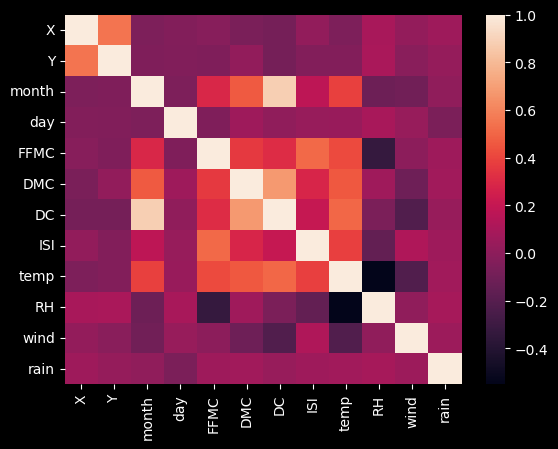

In [53]:
sns.heatmap(corrmatrix)

In [62]:
def correlation(df, thresold):
    cor_col_set = set()
    cor_matrix = df.corr()
    for i in range(len(cor_matrix.columns)):
        for j in range(i):
            if abs(cor_matrix.iloc[i, j]) > thresold:
                column_name = cor_matrix.columns[j]
                cor_col_set.add(column_name)
    return cor_col_set

In [55]:
x_train.shape, x_test.shape

((413, 12), (104, 12))

In [65]:
cor_col_set = correlation(x_train, 0.7)

In [67]:
x_train.drop(labels = cor_col_set, axis = 1, inplace = True)
x_test.drop(labels = cor_col_set, axis = 1, inplace = True)

In [68]:
x_train.shape, x_test.shape

((413, 11), (104, 11))

In [74]:
x_train.head(10)

,X,Y,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
304,0.556011,0.549135,0.822516,-0.933410,-1.280271,-1.809890,-1.169572,-1.281695,2.987612,0.492019,-0.070061
501,0.980471,0.549135,-1.126977,0.950579,1.080531,0.483317,1.117176,0.452135,1.241522,0.492019,2.392524
441,1.404931,1.350522,-1.614351,0.265492,1.479910,0.489077,-0.174413,1.108634,-0.926039,-1.267567,-0.070061
153,0.131552,-0.252253,0.335143,0.642290,-0.399789,0.570125,1.455954,0.199636,0.157741,0.492019,-0.070061
503,-1.141828,-0.252253,-0.639604,0.676544,0.437517,0.556959,2.324071,1.731466,-0.865829,0.492019,-0.070061
131,-0.292908,1.350522,-1.614351,-0.573739,-1.343493,-2.011893,-1.042530,-0.827196,-0.323939,-0.529676,-0.070061
204,0.131552,1.350522,0.822516,0.008584,-0.939489,-1.865020,-0.259107,-0.642029,1.181312,-0.018829,-0.070061
512,-0.292908,-1.053640,1.309890,-1.532861,-0.837717,0.460278,-1.508349,1.495800,-0.745409,-0.756719,-0.070061
325,-1.566287,-0.252253,0.822516,0.282619,-0.134565,0.813680,-0.132066,0.889801,-1.046459,-0.529676,-0.070061
247,-1.141828,-0.252253,-0.639604,0.282619,-0.299559,-0.206209,0.122017,0.300635,1.542572,-1.040524,-0.070061


In [75]:
x_test.head(10)

,X,Y,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
295,7.0,5.0,8.0,93.1,180.4,430.8,11.0,22.2,48.0,1.3,-2.580664e-17
471,4.0,3.0,6.0,89.6,25.4,73.7,5.7,18.0,40.0,4.0,-2.580664e-17
251,8.0,5.0,4.0,93.1,157.3,666.7,13.5,24.0,36.0,3.1,-2.580664e-17
506,1.0,2.0,6.0,91.0,166.9,752.6,7.1,18.5,73.0,8.5,-2.580664e-17
472,8.0,3.0,2.0,88.2,96.2,229.0,4.7,14.3,79.0,4.0,-2.580664e-17
303,3.0,6.0,6.0,91.1,94.1,232.1,7.1,19.2,38.0,4.5,-2.580664e-17
350,5.0,4.0,6.0,92.1,99.0,745.3,9.6,10.1,75.0,3.6,-2.580664e-17
269,4.0,4.0,3.0,92.1,152.6,658.2,14.3,19.1,53.0,2.7,-2.580664e-17
201,6.0,5.0,8.0,90.1,37.6,83.7,7.2,12.4,54.0,3.6,-2.580664e-17
161,6.0,4.0,5.0,95.2,131.7,578.8,10.4,20.3,41.0,4.0,-2.580664e-17


In [80]:
#Train and predict model after remove corlinear columns
model_after_rm_cor_col = Linear_Regression()
model_after_rm_cor_col.fit(x_test, y_test)
y_predict_after_rm_cor_col = model_after_rm_cor_col.predict(x_test)

#Calculate RMSE after remove colinear columns
rmse_after_rm_cor_col = model_after_rm_cor_col.rmse(y_test, y_predict_after_rm_cor_col)
print(rmse_after_rm_cor_col)

20.980086275765945


**REPORT FOR TASK 3:**
* **Feature Engineering:** Showing the correlation matrix in 2 ways. First, I use the method of pandas ".corr()", Second, I use seaborn library to visualize the correlation matrix. After that, I defind a function to find the columns that highly correlated features and I just keep one column in a pair. Finally, I drop the columns having in set() on both x_train and x_test.
* **Model Implementation:** Continued to use the Linear_Regression model that was built in task 1 to predict.
* **Evaluation:** The RMSE in task 3 after removing dependent columns is about **20.98**. It is lower than the model that trained on the original dataset.

### Assignment 4 (2 scores):

- Implement the Linear Regression model using Machine Learning libraries (Scikit Learn or Skorch).
- Compare the results of Linear Regression model constructed manually and from Machine Learning libraries.

In [78]:
#pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 3.8 MB/s  0:00:09 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [84]:
#Train and predict on Linear Regression model from scikit learn library
model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

#Calculate RMSE
rmse = root_mean_squared_error(y_test, y_predict)
print(rmse)

259.80324871054853


**REPORT FOR TASK 4:**
* **Model Implementation:** Utilized the Linear Regression from scikit-learn library
* **Evaluation:** The RMSE in task 4 when using model from Machine Learning library is about **259.8**. The RMSE of model from scikit-learn  is twelve times greater than the one that was constructed manually